# Sentiment Analysis: British Airways Reviews

Klasifikasi biner kolom `recommended` (yes / no) dari kolom teks `content` menggunakan **TF-IDF + 4 model** (Logistic Regression, Linear SVM, Multinomial Naive Bayes, dan ComplementNB sebagai varian modern untuk teks).

## Tahapan Implementasi dan Analisis
1. Import Library
2. Load Dataset
3. EDA (Exploratory Data Analysis)
4. Praproses
5. Train-Test Split
6. Vectorisasi / Embedding (TF-IDF)
7. Training Model + Hyperparameter Tuning
8. Prediction
9. Evaluasi Model (Classification Report, Confusion Matrix, ROC Curve)
10. Analisis Error
11. Diskusi
12. Kesimpulan

## 1. Import Library

In [ ]:
!pip install -q wordcloud

In [ ]:
# ===== Core =====
import re
import string
import warnings
import numpy as np
import pandas as pd
from scipy.special import expit


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.calibration import CalibratedClassifierCV


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Download resource NLTK
for pkg in ['stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f'Gagal mengunduh {pkg}: {e}')

RANDOM_STATE = 42
print('Setup selesai.')

Setup selesai.


## 2. Load Dataset

In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

!kaggle datasets download -d dharun4772/british-airline-review-dataset
!unzip -o british-airline-review-dataset.zip -d british-airline-review-dataset

Dataset URL: https://www.kaggle.com/datasets/dharun4772/british-airline-review-dataset
License(s): MIT
100% 1.25M/1.25M [00:00<00:00, 161MB/s]

Archive:  british-airline-review-dataset.zip
  inflating: british-airline-review-dataset/airline_review.csv  


In [ ]:
DATA_PATH = '/content/british-airline-review-dataset/airline_review.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape dataset : {df.shape}')
print(f'Kolom tersedia: {list(df.columns)}')
df.head()

Shape dataset : (3616, 20)
Kolom tersedia: ['Unnamed: 0', 'rating', 'header', 'author', 'date', 'place', 'content', 'aircraft', 'traveller_type', 'seat_type', 'route', 'date_flown', 'seat_comfort', 'cabin_staff_service', 'food_beverages', 'ground_service', 'value_for_money', 'recommended', 'entertainment', 'trip_verified']


,Unnamed: 0,rating,header,author,date,place,content,aircraft,traveller_type,seat_type,route,date_flown,seat_comfort,cabin_staff_service,food_beverages,ground_service,value_for_money,recommended,entertainment,trip_verified
0,0,2,service was mediocre at best,Gary Storer,2023-10-03,United Kingdom,"Just returned from Chicago, flew out 10 days ...",A380,Couple Leisure,Economy Class,Chicago to Manchester via Heathrow,2023-10-01,2,3,1,2,2,no,-1,Not Verified
1,1,2,BA standards continue to decline,A Jensen,2023-10-02,United Kingdom,BA standards continue to decline every time ...,A320,Business,Business Class,London Heathrow to Munich,2023-09-01,2,1,2,1,1,no,-1,Verified
2,2,2,"won the race to the bottom""",John Rockett,2023-10-02,United Kingdom,Awful. Business class check in queue just as...,A320,Couple Leisure,Business Class,Heathrow to Istanbul,2023-09-01,2,3,2,1,1,no,-1,Not Verified
3,3,3,Not a reliable airline,Tatiana Bobrovskaya,2023-10-02,United Kingdom,Not a reliable airline. You cannot trust the...,A320,Business,Economy Class,London to Geneva,2023-10-01,4,4,2,1,1,no,-1,Verified
4,4,1,It is a national disgrace,A Dawson,2023-09-30,United Kingdom,I take comfort in reading the last ten or so...,NaN,Couple Leisure,Business Class,Athens to London,2023-09-01,1,1,1,1,1,no,1,Verified


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           3616 non-null   int64 
 1   rating               3616 non-null   int64 
 2   header               3616 non-null   object
 3   author               3616 non-null   object
 4   date                 3616 non-null   object
 5   place                3616 non-null   object
 6   content              3616 non-null   object
 7   aircraft             1902 non-null   object
 8   traveller_type       2895 non-null   object
 9   seat_type            3614 non-null   object
 10  route                2891 non-null   object
 11  date_flown           2888 non-null   object
 12  seat_comfort         3616 non-null   int64 
 13  cabin_staff_service  3616 non-null   int64 
 14  food_beverages       3616 non-null   int64 
 15  ground_service       3616 non-null   int64 
 16  value_

## 3. EDA (Exploratory Data Analysis)

### 3.1 Null Values & Duplikat Handling

In [ ]:
print('Jumlah nilai null per kolom:')
print(df.isnull().sum())

before = len(df)
df = df.dropna(subset=['content', 'recommended']).reset_index(drop=True)
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)
after = len(df)
print(f'\nBaris sebelum  : {before}')
print(f'Baris sesudah  : {after}')
print(f'Dihapus        : {before - after} (NaN + duplikat)')

Jumlah nilai null per kolom:
Unnamed: 0                0
rating                    0
header                    0
author                    0
date                      0
place                     0
content                   0
aircraft               1714
traveller_type          721
seat_type                 2
route                   725
date_flown              728
seat_comfort              0
cabin_staff_service       0
food_beverages            0
ground_service            0
value_for_money           0
recommended               0
entertainment             0
trip_verified          1474
dtype: int64

Baris sebelum  : 3616
Baris sesudah  : 3557
Dihapus        : 59 (NaN + duplikat)


### 3.2 Target Checking — Distribusi `recommended`
Memeriksa class balance lewat tabel, **bar chart**, dan **pie chart proporsi sentimen (%)**.

Distribusi label:
             count  percent (%)
recommended                    
no            2127         59.8
yes           1430         40.2


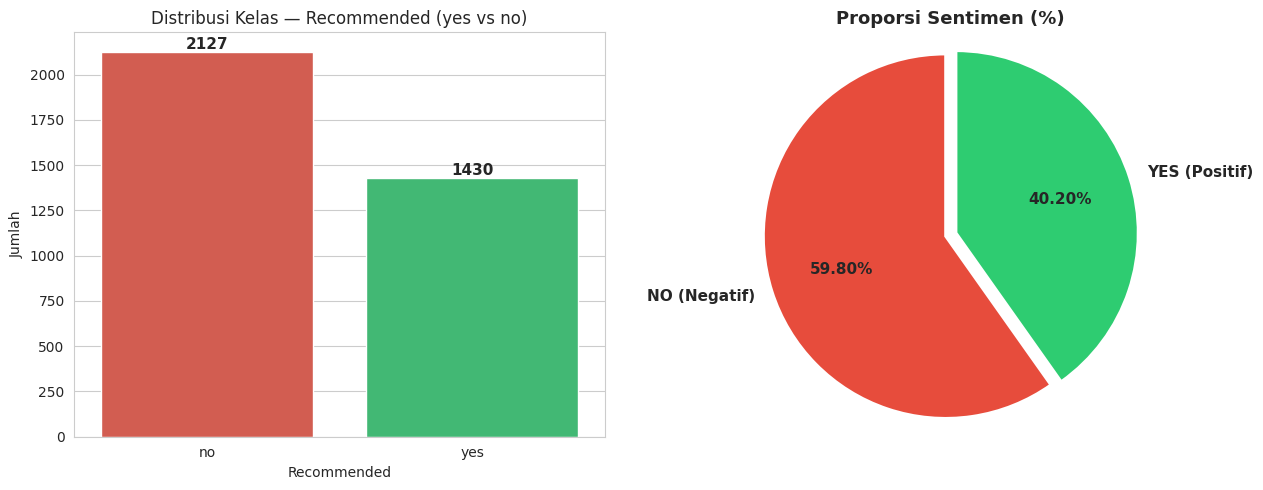


Imbalance ratio (mayoritas / minoritas): 1.49
Kelas relatif seimbang.


In [ ]:
df['recommended'] = df['recommended'].astype(str).str.strip().str.lower()

target_counts = df['recommended'].value_counts()
target_pct = df['recommended'].value_counts(normalize=True) * 100
summary = pd.concat([
    target_counts.rename('count'),
    target_pct.round(2).rename('percent (%)')
], axis=1)
print('Distribusi label:')
print(summary)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Bar chart ---
sns.countplot(x='recommended', data=df, palette={'yes': '#2ecc71', 'no': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Distribusi Kelas — Recommended (yes vs no)')
axes[0].set_xlabel('Recommended')
axes[0].set_ylabel('Jumlah')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Pie chart proporsi sentimen ---
colors = {'yes': '#2ecc71', 'no': '#e74c3c'}
labels = [f"{lbl.upper()} ({'Positif' if lbl=='yes' else 'Negatif'})" for lbl in target_counts.index]
axes[1].pie(
    target_counts.values,
    labels=labels,
    colors=[colors[l] for l in target_counts.index],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    explode=[0.03] * len(target_counts),
)
axes[1].set_title('Proporsi Sentimen (%)', fontsize=13, fontweight='bold')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'\nImbalance ratio (mayoritas / minoritas): {imbalance_ratio:.2f}')
if imbalance_ratio > 1.5:
    print("Kelas tidak seimbang — kita gunakan stratify=y dan class_weight='balanced'.")
else:
    print('Kelas relatif seimbang.')

### 3.3 Statistik Panjang Review

       content_length  word_count
count         3557.00     3557.00
mean           883.73      160.44
std            573.86      106.25
min             83.00       15.00
25%            477.00       86.00
50%            735.00      133.00
75%           1110.00      202.00
max           3529.00      654.00


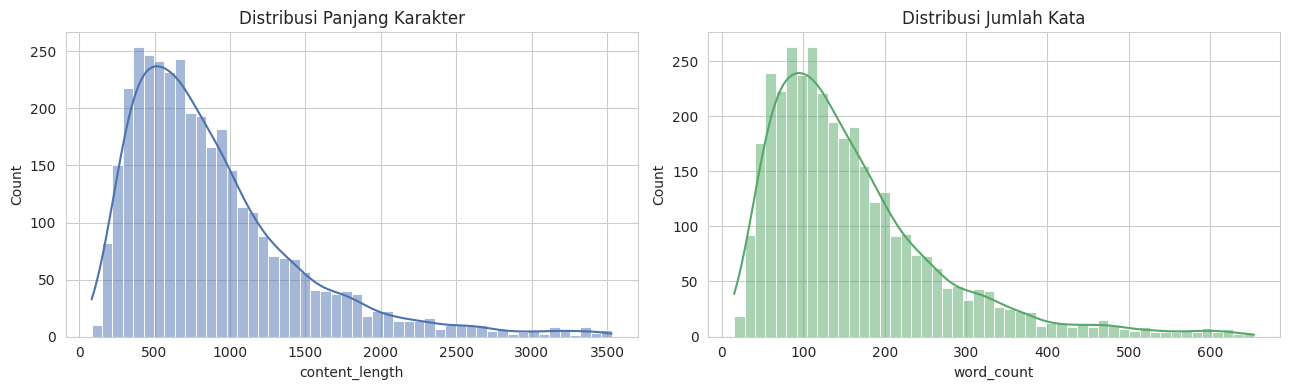

In [ ]:
df['content_length'] = df['content'].astype(str).apply(len)
df['word_count']     = df['content'].astype(str).apply(lambda x: len(x.split()))

print(df[['content_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['content_length'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribusi Panjang Karakter')
sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Distribusi Jumlah Kata')
plt.tight_layout()
plt.show()

### 3.4 Custom Airline Stopwords
Beberapa kata sangat sering muncul dalam ulasan maskapai (`flight`, `airline`, `british`, `airways`, dll.) tetapi **tidak informatif** untuk membedakan sentimen positif vs negatif. Kita tambahkan ke stopwords agar TF-IDF dan WordCloud lebih bermakna.

In [ ]:
CUSTOM_AIRLINE_STOPWORDS = {
    # Brand & maskapai
    'british', 'airways', 'airway', 'ba', 'airline', 'airlines',
    # Objek pesawat & penerbangan generik
    'flight', 'flights', 'plane', 'planes', 'airplane', 'aircraft',
    'flying', 'fly', 'flew', 'flown',
    # Bandara / kota umum di rute British Airways
    'london', 'heathrow', 'lhr', 'gatwick', 'lgw', 'airport', 'airports',
    'terminal', 'gate',
    # Aktor dalam review
    'passenger', 'passengers', 'people', 'staff', 'crew', 'customer', 'customers',
    # Konsep generik travel
    'travel', 'travelling', 'traveling', 'trip', 'journey', 'route',
    'class', 'cabin', 'seat', 'seats', 'business', 'economy', 'premium',
    # Kata fungsional yang sering bocor lewat
    'get', 'got', 'getting', 'go', 'going', 'went', 'gone',
    'one', 'two', 'three', 'first', 'second', 'last', 'next',
    'time', 'hour', 'hours', 'minute', 'minutes', 'day', 'days',
    'would', 'could', 'should', 'also', 'us', 'u',
    'take', 'took', 'taken', 'taking', 'said', 'say', 'told',
    'really', 'even', 'still', 'much', 'many', 'lot', 'every',
}
print(f'Total custom airline stopwords: {len(CUSTOM_AIRLINE_STOPWORDS)}')
print('Sample:', sorted(list(CUSTOM_AIRLINE_STOPWORDS))[:15])

Total custom airline stopwords: 86
Sample: ['aircraft', 'airline', 'airlines', 'airplane', 'airport', 'airports', 'airway', 'airways', 'also', 'ba', 'british', 'business', 'cabin', 'class', 'could']


### 3.5 WordCloud — Sentimen Positif vs Negatif (Terpisah)

In [ ]:
# Cleaning ringan khusus untuk WordCloud (lowercase + remove non-letter + remove stopwords)
STOPWORDS_EN = set(stopwords.words('english'))
WC_STOPWORDS = STOPWORDS_EN | CUSTOM_AIRLINE_STOPWORDS

def light_clean(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

pos_text = ' '.join(df.loc[df['recommended'] == 'yes', 'content'].astype(str).map(light_clean))
neg_text = ' '.join(df.loc[df['recommended'] == 'no',  'content'].astype(str).map(light_clean))

wc_common = dict(
    width=900,
    height=450,
    background_color='white',
    stopwords=WC_STOPWORDS,
    max_words=120,
    collocations=True,        # tampilkan bigram populer (mis. 'good service')
    contour_width=1,
    random_state=RANDOM_STATE,
)

wc_pos = WordCloud(colormap='Greens', contour_color='#2ecc71', **wc_common).generate(pos_text)
wc_neg = WordCloud(colormap='Reds',   contour_color='#e74c3c', **wc_common).generate(neg_text)

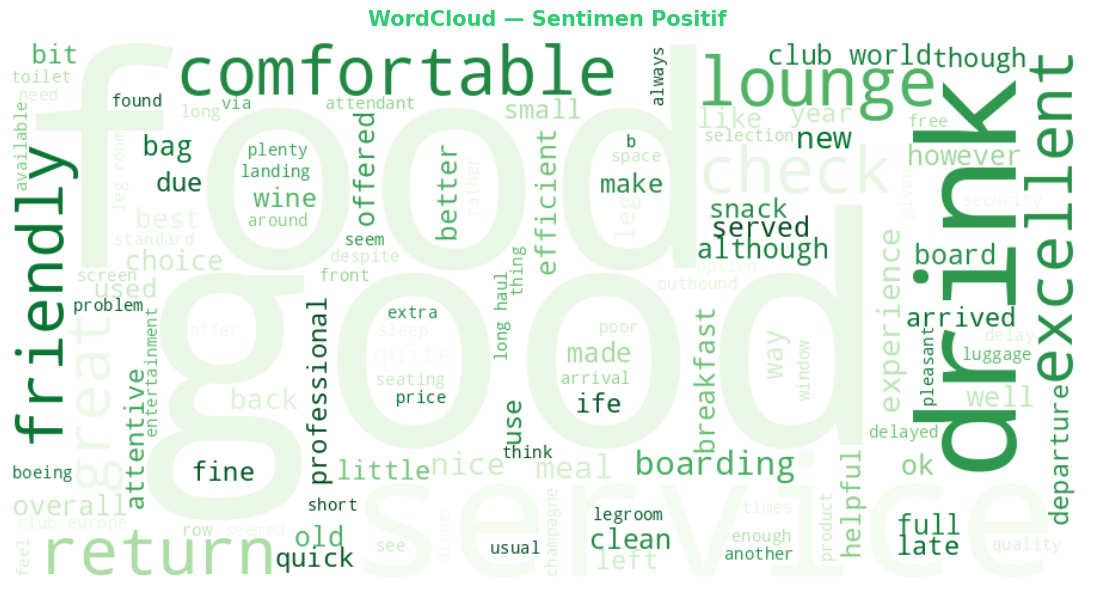

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_pos, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Sentimen Positif',
             fontsize=15, fontweight='bold', color='#2ecc71', pad=12)
plt.tight_layout()
plt.show()

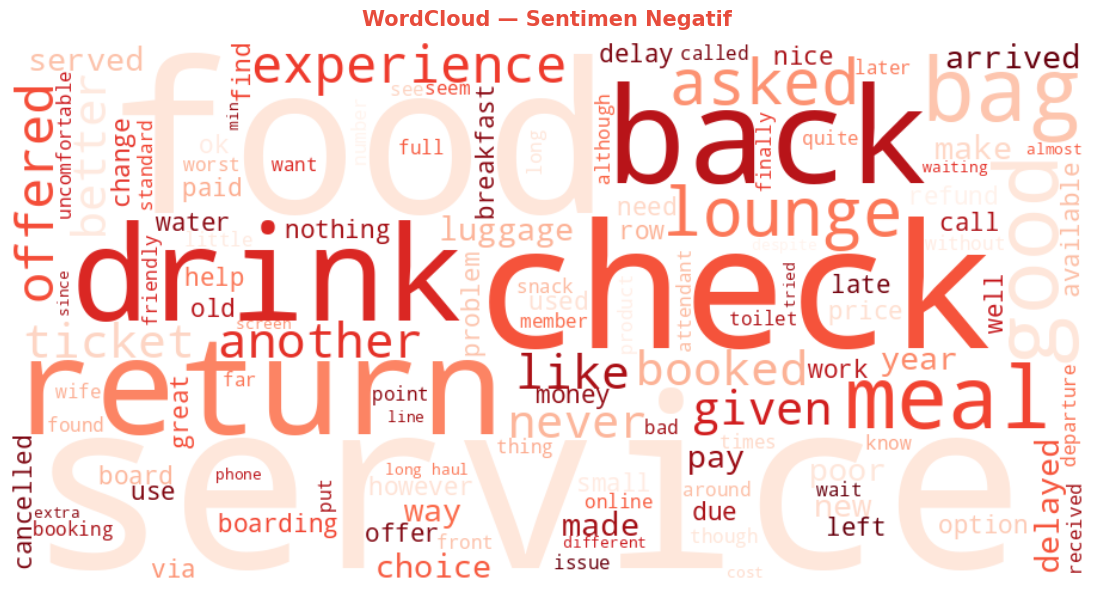

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_neg, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Sentimen Negatif',
             fontsize=15, fontweight='bold', color='#e74c3c', pad=12)
plt.tight_layout()
plt.show()

## 4. Praproses
Tahapan: **Case Folding → Noise Removal (regex) → Tokenisasi → Stopwords Removal (English + Custom Airline) → Lemmatization**.

**Penting:** Kata negasi (`not`, `never`, `no`, `n't`, dst.) **sengaja dipertahankan** karena sangat krusial untuk konteks sentimen (mis. *"not recommended"*, *"never again"*).

In [ ]:
lemmatizer = WordNetLemmatizer()

NEGATION_KEEP = {
    'no', 'nor', 'not', 'never', 'none', 'nothing',
    "n't", "don't", "didn't", "doesn't", "isn't", "wasn't",
    "weren't", "aren't", "won't", "wouldn't", "shouldn't",
    "can't", "cannot", "couldn't", "hadn't", "hasn't", "haven't",
}
STOPWORDS_FINAL = (STOPWORDS_EN - NEGATION_KEEP) | CUSTOM_AIRLINE_STOPWORDS
print(f'Total stopwords yang akan dibuang: {len(STOPWORDS_FINAL)}')

Total stopwords yang akan dibuang: 266


In [ ]:
# Pola regex pre-compile untuk efisiensi
RE_URL      = re.compile(r'https?://\S+|www\.\S+')
RE_HTML     = re.compile(r'<.*?>')
RE_EMOJI    = re.compile(
    '[\U0001F600-\U0001F64F'
    '\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF'
    '\U0001F1E0-\U0001F1FF'
    '\U00002700-\U000027BF'
    '\U0001F900-\U0001F9FF'
    '\U00002600-\U000026FF]+', flags=re.UNICODE)
RE_NUMBER   = re.compile(r'\d+')
RE_PUNCT    = re.compile(f'[{re.escape(string.punctuation)}]')
RE_NONASCII = re.compile(r'[^\x00-\x7F]+')
RE_MULTISPC = re.compile(r'\s+')

def clean_text(text: str) -> str:
    """Pipeline preprocessing lengkap: case fold → noise removal → tokenize → stopwords → lemmatize."""
    if not isinstance(text, str):
        return ''

    # 1) Case folding
    text = text.lower()

    # 2) Noise removal
    text = RE_URL.sub(' ', text)
    text = RE_HTML.sub(' ', text)
    text = RE_EMOJI.sub(' ', text)
    text = RE_NONASCII.sub(' ', text)
    text = RE_NUMBER.sub(' ', text)
    text = RE_PUNCT.sub(' ', text)
    text = RE_MULTISPC.sub(' ', text).strip()

    # 3) Tokenisasi
    tokens = text.split()

    # 4) Stopwords removal (English + Custom Airline; negasi dipertahankan)
    tokens = [t for t in tokens if t not in STOPWORDS_FINAL and len(t) > 1]

    # 5) Lemmatization (verb + noun → delayed/delays/delaying ➜ delay)
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]

    # Filter kembali jika lemmatization menghasilkan stopword (mis. 'flying' → 'fly')
    tokens = [t for t in tokens if t not in STOPWORDS_FINAL]

    return ' '.join(tokens)

# Smoke test
sample = "The British Airways flight was DELAYED for 3 hours!! Not good at all 😡 https://ba.com"
print('Sebelum :', sample)
print('Sesudah :', clean_text(sample))

Sebelum : The British Airways flight was DELAYED for 3 hours!! Not good at all 😡 https://ba.com
Sesudah : delay not good


In [ ]:
# Apply preprocessing ke seluruh dataset
print('Membersihkan teks...')
df['clean_content'] = df['content'].astype(str).apply(clean_text)

# Buang baris yang menjadi kosong setelah preprocessing
before = len(df)
df = df[df['clean_content'].str.strip().astype(bool)].reset_index(drop=True)
print(f'Dihapus {before - len(df)} baris yang menjadi kosong setelah cleaning.\n')

df[['content', 'clean_content']].head(5)

Membersihkan teks...
Dihapus 0 baris yang menjadi kosong setelah cleaning.



,content,clean_content
0,"Just returned from Chicago, flew out 10 days ...",return chicago ago american absolutely superb ...
1,BA standards continue to decline every time ...,standard continue decline min late departure s...
2,Awful. Business class check in queue just as...,awful check queue long probably half desk not ...
3,Not a reliable airline. You cannot trust the...,not reliable cannot trust board sit already ex...
4,I take comfort in reading the last ten or so...,comfort read ten review see not traveller put ...


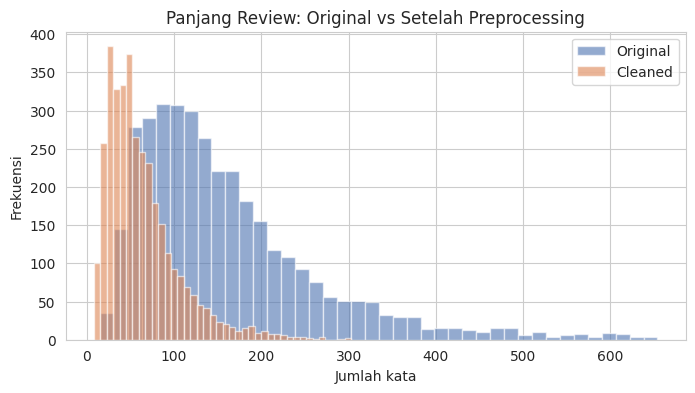

Label encoding: {'yes': 1, 'no': 0}
label
no (0)     2127
yes (1)    1430
Name: count, dtype: int64


In [ ]:
# Label encoding: yes → 1, no → 0
label_map = {'yes': 1, 'no': 0}
df['label'] = df['recommended'].map(label_map)
assert df['label'].notna().all(), 'Ada nilai recommended di luar {yes, no} — periksa dataset.'
df['label'] = df['label'].astype(int)

# Perbandingan panjang sebelum vs sesudah preprocessing
df['clean_word_count'] = df['clean_content'].apply(lambda x: len(x.split()))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['word_count'],       bins=40, alpha=0.6, label='Original', color='#4C72B0')
ax.hist(df['clean_word_count'], bins=40, alpha=0.6, label='Cleaned',  color='#DD8452')
ax.set_xlabel('Jumlah kata'); ax.set_ylabel('Frekuensi')
ax.set_title('Panjang Review: Original vs Setelah Preprocessing')
ax.legend(); plt.show()

print('Label encoding:', label_map)
print(df['label'].value_counts().rename({1: 'yes (1)', 0: 'no (0)'}))

## 5. Train-Test Split
Split 80/20 dengan `stratify=y` untuk menjaga proporsi kelas pada kedua subset.

In [ ]:
X = df['clean_content'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Total samples : {len(X)}')
print(f'Train samples : {len(X_train)} ({len(X_train)/len(X):.1%})')
print(f'Test  samples : {len(X_test)}  ({len(X_test)/len(X):.1%})')
print('\nDistribusi kelas:')
print('  Train :', dict(zip(*np.unique(y_train, return_counts=True))))
print('  Test  :', dict(zip(*np.unique(y_test,  return_counts=True))))

Total samples : 3557
Train samples : 2845 (80.0%)
Test  samples : 712  (20.0%)

Distribusi kelas:
  Train : {np.int64(0): np.int64(1701), np.int64(1): np.int64(1144)}
  Test  : {np.int64(0): np.int64(426), np.int64(1): np.int64(286)}


## 6. Vectorisasi / Embedding (TF-IDF)
Mengubah teks bersih menjadi vektor numerik dengan **TF-IDF Unigram + Bigram**.
- `ngram_range=(1, 2)` → menangkap konteks negasi (`not good`, `never recommend`).
- `max_features=10000` → batasi 10k fitur paling populer.
- `min_df=2`, `max_df=0.95` → buang term ekstrem.
- `sublinear_tf=True` → 1 + log(tf) untuk teks panjang yang bervariasi.

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

# Fit hanya pada training set, transform pada keduanya (mencegah data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Shape X_train_tfidf : {X_train_tfidf.shape}')
print(f'Shape X_test_tfidf  : {X_test_tfidf.shape}')
print(f'Total fitur (vocab) : {len(tfidf.vocabulary_)}')

feature_names = np.array(tfidf.get_feature_names_out())
unigrams = [f for f in feature_names if ' ' not in f][:10]
bigrams  = [f for f in feature_names if ' ' in f][:10]
print('\nContoh unigram :', unigrams)
print('Contoh bigram  :', bigrams)

Shape X_train_tfidf : (2845, 10000)
Shape X_test_tfidf  : (712, 10000)
Total fitur (vocab) : 10000

Contoh unigram : ['aa', 'abandon', 'aberdeen', 'ability', 'able', 'aboard', 'abreast', 'abroad', 'abrupt', 'abruptly']
Contoh bigram  : ['able board', 'able book', 'able change', 'able check', 'able choose', 'able find', 'able make', 'able secure', 'able select', 'able sit']


## 7. Training Model + Hyperparameter Tuning
Kita melatih **4 model** sekaligus dan mencari hyperparameter terbaik via `GridSearchCV` (5-fold stratified, scoring `f1_weighted`):

| # | Model | Alasan |
|---|---|---|
| 1 | **Logistic Regression** | Baseline kuat & interpretable untuk TF-IDF |
| 2 | **Linear SVM** (`LinearSVC`) | Sangat efektif pada matriks sparse berdimensi tinggi |
| 3 | **Multinomial Naive Bayes** | Cepat, klasik untuk klasifikasi teks |
| 4 | **ComplementNB** ⭐ | Varian Naive Bayes **modern** (Rennie et al., 2003) — dirancang khusus untuk teks dengan **class imbalance**, biasanya **mengalahkan MultinomialNB** |

Grid yang lebih luas dibandingkan iterasi sebelumnya untuk memaksimalkan performa.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'f1_weighted'

tuning_results = {}  # menyimpan best CV score untuk perbandingan

# --------- 7.1 Logistic Regression ---------
print('>> [1/4] Tuning Logistic Regression...')
lr_base = LogisticRegression(
    max_iter=4000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr_param_grid = [
    {'solver': ['liblinear'],
     'penalty': ['l1', 'l2'],
     'C': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]},
    {'solver': ['saga'],
     'penalty': ['elasticnet'],
     'C': [0.1, 1, 5],
     'l1_ratio': [0.3, 0.5, 0.7]},
]
lr_grid = GridSearchCV(lr_base, lr_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=0)
lr_grid.fit(X_train_tfidf, y_train)
tuning_results['Logistic Regression'] = lr_grid.best_score_
print(f'   Best params : {lr_grid.best_params_}')
print(f'   Best CV f1  : {lr_grid.best_score_:.4f}')

>> [1/4] Tuning Logistic Regression...
   Best params : {'C': 2, 'penalty': 'l2', 'solver': 'liblinear'}
   Best CV f1  : 0.8302


In [ ]:
# --------- 7.2 Linear SVM ---------
print('>> [2/4] Tuning Linear SVM...')
svm_base = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=8000,
    dual='auto',
)
svm_param_grid = [
    {'penalty': ['l2'], 'loss': ['hinge', 'squared_hinge'],
     'C': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]},
    {'penalty': ['l1'], 'loss': ['squared_hinge'],
     'C': [0.05, 0.1, 0.5, 1, 2]},
]
svm_grid = GridSearchCV(svm_base, svm_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=0)
svm_grid.fit(X_train_tfidf, y_train)
tuning_results['Linear SVM'] = svm_grid.best_score_
print(f'   Best params : {svm_grid.best_params_}')
print(f'   Best CV f1  : {svm_grid.best_score_:.4f}')

>> [2/4] Tuning Linear SVM...
   Best params : {'C': 0.5, 'loss': 'hinge', 'penalty': 'l2'}
   Best CV f1  : 0.8308


In [ ]:
# --------- 7.3 Multinomial Naive Bayes ---------
print('>> [3/4] Tuning Multinomial Naive Bayes...')
mnb_base = MultinomialNB()
mnb_param_grid = {
    'alpha':     [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False],
}
mnb_grid = GridSearchCV(mnb_base, mnb_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=0)
mnb_grid.fit(X_train_tfidf, y_train)
tuning_results['Multinomial Naive Bayes'] = mnb_grid.best_score_
print(f'   Best params : {mnb_grid.best_params_}')
print(f'   Best CV f1  : {mnb_grid.best_score_:.4f}')

>> [3/4] Tuning Multinomial Naive Bayes...
   Best params : {'alpha': 0.5, 'fit_prior': False}
   Best CV f1  : 0.8238


In [ ]:
# --------- 7.4 Complement Naive Bayes (Modern variant) ---------
print('>> [4/4] Tuning Complement Naive Bayes (varian modern untuk class imbalance)...')
cnb_base = ComplementNB()
cnb_param_grid = {
    'alpha':     [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False],
    'norm':      [False, True],
}
cnb_grid = GridSearchCV(cnb_base, cnb_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=0)
cnb_grid.fit(X_train_tfidf, y_train)
tuning_results['ComplementNB'] = cnb_grid.best_score_
print(f'   Best params : {cnb_grid.best_params_}')
print(f'   Best CV f1  : {cnb_grid.best_score_:.4f}')

>> [4/4] Tuning Complement Naive Bayes (varian modern untuk class imbalance)...
   Best params : {'alpha': 0.5, 'fit_prior': True, 'norm': False}
   Best CV f1  : 0.8238


In [ ]:
# Ringkasan skor cross-validation
cv_summary = pd.DataFrame(
    [{'Model': k, 'Best CV F1 (weighted)': v} for k, v in tuning_results.items()]
).sort_values('Best CV F1 (weighted)', ascending=False).reset_index(drop=True)
print('=== Ringkasan Cross-Validation (5-fold stratified) ===')
print(cv_summary.round(4).to_string(index=False))

=== Ringkasan Cross-Validation (5-fold stratified) ===
                  Model  Best CV F1 (weighted)
             Linear SVM                 0.8308
    Logistic Regression                 0.8302
Multinomial Naive Bayes                 0.8238
           ComplementNB                 0.8238


## 8. Prediction
Memprediksi label test set dan **probability score** dari masing-masing model. Untuk `LinearSVC` yang tidak memiliki `predict_proba`, kita gunakan `decision_function` lalu **konversi via sigmoid** sebagai pseudo-probability.

In [ ]:
models = {
    'Logistic Regression':     lr_grid.best_estimator_,
    'Linear SVM':              svm_grid.best_estimator_,
    'Multinomial Naive Bayes': mnb_grid.best_estimator_,
    'ComplementNB':            cnb_grid.best_estimator_,
}

def get_proba(model, X):
    """Return probabilitas kelas positif (label=1). Pakai predict_proba jika tersedia,
    fallback ke sigmoid(decision_function) untuk LinearSVC."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        return expit(model.decision_function(X))
    else:
        raise ValueError(f'Model {type(model).__name__} tidak punya proba/decision_function.')

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name]   = model.predict(X_test_tfidf)
    probabilities[name] = get_proba(model, X_test_tfidf)

print('Prediksi & probabilitas dihitung untuk:', list(models.keys()))

Prediksi & probabilitas dihitung untuk: ['Logistic Regression', 'Linear SVM', 'Multinomial Naive Bayes', 'ComplementNB']


## 9. Evaluasi Model
Tiga komponen evaluasi: **(a) tabel ringkasan metrik**, **(b) classification report + confusion matrix**, **(c) ROC Curve**.

### 9.1 Ringkasan Metrik (Test Set)

In [ ]:
results = []
for name, model in models.items():
    y_pred  = predictions[name]
    y_score = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    results.append({
        'Model':          name,
        'Accuracy':       accuracy_score(y_test, y_pred),
        'F1 (weighted)':  f1_score(y_test, y_pred, average='weighted'),
        'F1 (macro)':     f1_score(y_test, y_pred, average='macro'),
        'ROC AUC':        auc(fpr, tpr),
    })

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
print('=== Ringkasan Performa pada Test Set ===')
print(results_df.round(4).to_string(index=False))

=== Ringkasan Performa pada Test Set ===
                  Model  Accuracy  F1 (weighted)  F1 (macro)  ROC AUC
           ComplementNB    0.8174         0.8176      0.8105   0.8699
Multinomial Naive Bayes    0.8174         0.8176      0.8105   0.8699
    Logistic Regression    0.8160         0.8167      0.8102   0.8803
             Linear SVM    0.8146         0.8151      0.8082   0.8777


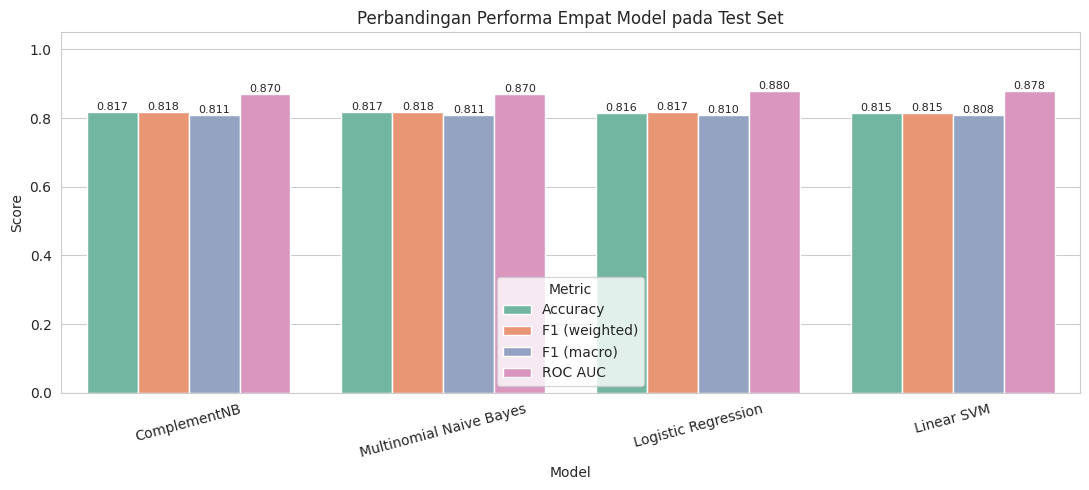

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
results_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melt, x='Model', y='Score', hue='Metric', palette='Set2', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Perbandingan Performa Empat Model pada Test Set')
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.3f}', (p.get_x() + p.get_width()/2., h),
                    ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 9.2 Classification Report (per Model)

In [ ]:
for name in models.keys():
    print('=' * 72)
    print(f'Classification Report — {name}')
    print('=' * 72)
    print(classification_report(
        y_test, predictions[name],
        target_names=['no (0)', 'yes (1)'],
        digits=4,
    ))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

      no (0)     0.8589    0.8286    0.8435       426
     yes (1)     0.7575    0.7972    0.7768       286

    accuracy                         0.8160       712
   macro avg     0.8082    0.8129    0.8102       712
weighted avg     0.8181    0.8160    0.8167       712

Classification Report — Linear SVM
              precision    recall  f1-score   support

      no (0)     0.8534    0.8333    0.8432       426
     yes (1)     0.7601    0.7867    0.7732       286

    accuracy                         0.8146       712
   macro avg     0.8068    0.8100    0.8082       712
weighted avg     0.8159    0.8146    0.8151       712

Classification Report — Multinomial Naive Bayes
              precision    recall  f1-score   support

      no (0)     0.8507    0.8427    0.8467       426
     yes (1)     0.7690    0.7797    0.7743       286

    accuracy                         0.8174       712
 

### 9.3 Confusion Matrix (per Model)

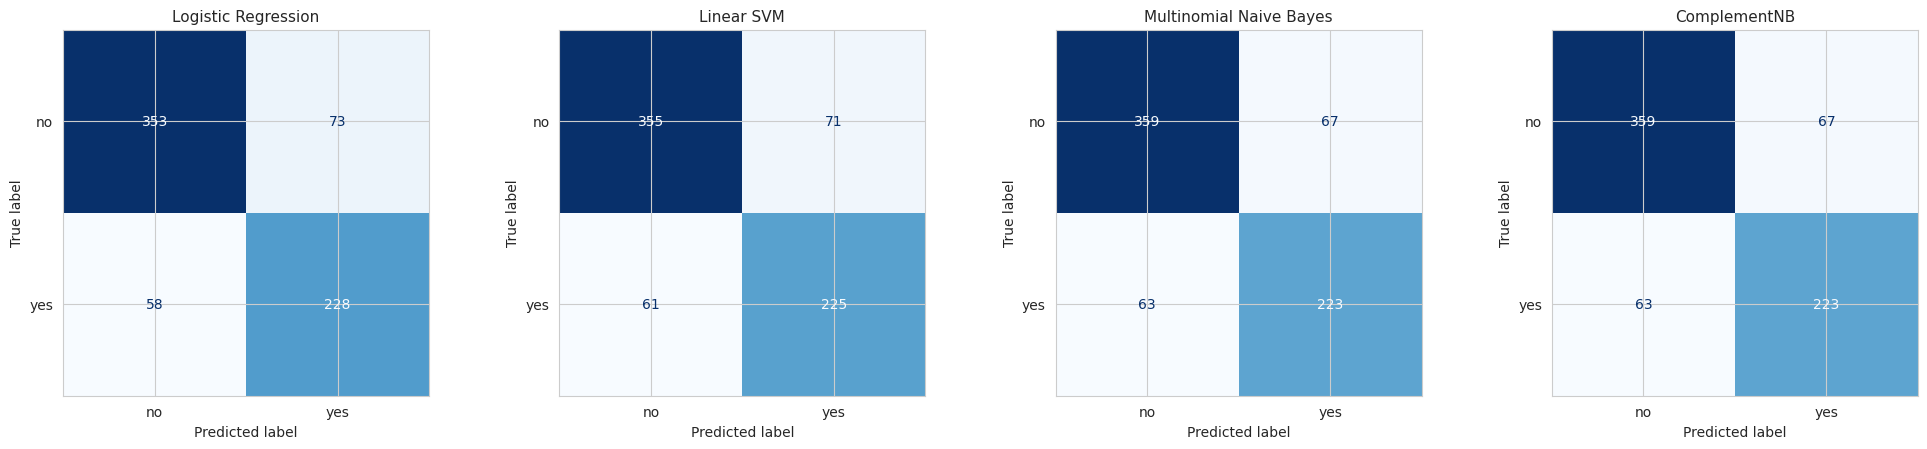

In [ ]:
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontsize=11)
plt.tight_layout()
plt.show()

### 9.4 ROC Curve (Multi-Model Comparison)
Receiver Operating Characteristic curve memvisualisasikan trade-off **True Positive Rate vs False Positive Rate** pada berbagai threshold. Kurva yang lebih dekat ke pojok kiri-atas (AUC mendekati 1.0) menunjukkan diskriminasi yang lebih baik.

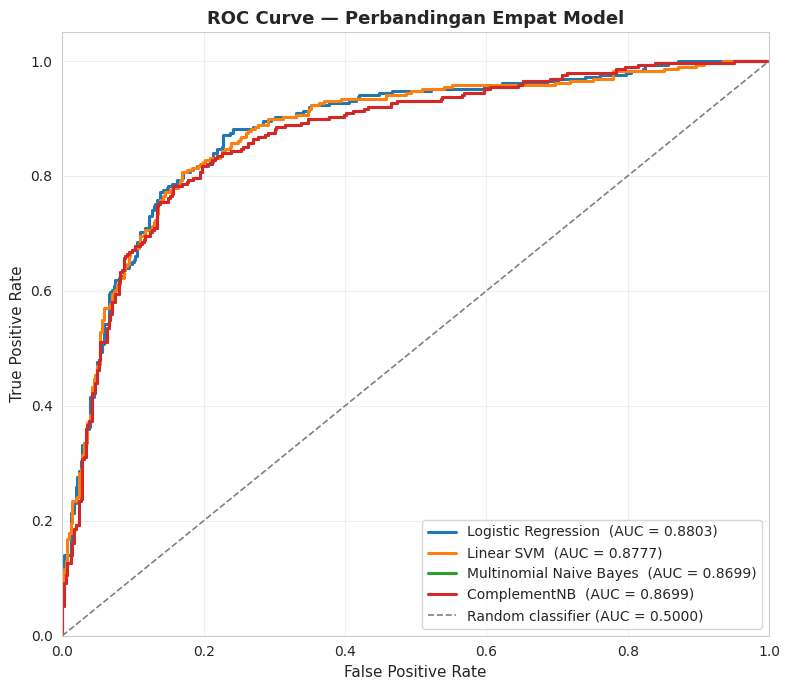

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
palette = {
    'Logistic Regression':     '#1f77b4',
    'Linear SVM':              '#ff7f0e',
    'Multinomial Naive Bayes': '#2ca02c',
    'ComplementNB':            '#d62728',
}

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.2, color=palette[name],
            label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--', label='Random classifier (AUC = 0.5000)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Perbandingan Empat Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.5 Pemilihan Model Terbaik

  MODEL TERBAIK : ComplementNB
Accuracy        : 0.8174
F1 (weighted)   : 0.8176
F1 (macro)      : 0.8105
ROC AUC         : 0.8699
Best params     : {'alpha': 0.5, 'class_prior': None, 'fit_prior': True, 'force_alpha': True, 'norm': False}


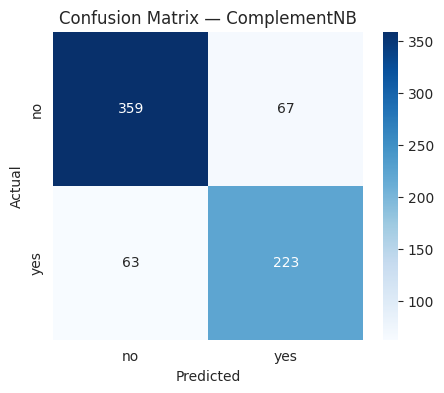

In [ ]:
best_row    = results_df.iloc[0]
best_name   = best_row['Model']
best_model  = models[best_name]

print('=' * 72)
print(f'  MODEL TERBAIK : {best_name}')
print('=' * 72)
print(f'Accuracy        : {best_row["Accuracy"]:.4f}')
print(f'F1 (weighted)   : {best_row["F1 (weighted)"]:.4f}')
print(f'F1 (macro)      : {best_row["F1 (macro)"]:.4f}')
print(f'ROC AUC         : {best_row["ROC AUC"]:.4f}')
print(f'Best params     : {best_model.get_params()}')

# Confusion matrix detail untuk model terbaik
y_pred_best = predictions[best_name]
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no', 'yes'], yticklabels=['no', 'yes'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.show()

## 10. Analisis Error
Memahami **kapan model salah** lebih penting daripada sekadar metrik. Cek:
1. Distribusi false positive vs false negative.
2. Contoh review yang salah klasifikasi.
3. Top fitur per kelas (interpretasi).

In [ ]:
error_df = pd.DataFrame({
    'review':      X_test,
    'true_label':  y_test,
    'pred_label':  y_pred_best,
    'prob_yes':    probabilities[best_name],
})
errors = error_df[error_df['true_label'] != error_df['pred_label']].copy()
errors['error_type'] = np.where(
    (errors['true_label'] == 1) & (errors['pred_label'] == 0),
    'False Negative (yes ➜ predicted no)',
    'False Positive (no ➜ predicted yes)'
)
print(f'Total prediksi salah : {len(errors)} / {len(error_df)}  ({len(errors)/len(error_df):.2%})')
print('\nDistribusi tipe error:')
print(errors['error_type'].value_counts())

Total prediksi salah : 130 / 712  (18.26%)

Distribusi tipe error:
error_type
False Positive (no ➜ predicted yes)    67
False Negative (yes ➜ predicted no)    63
Name: count, dtype: int64


In [ ]:
# Sampel False Positive — model PD bahwa positif padahal sebenarnya negatif
fp = errors[errors['error_type'].str.startswith('False Positive')] \
    .sort_values('prob_yes', ascending=False).head(5)
print('--- 5 Sampel FALSE POSITIVE paling "yakin" (model salah PD positif) ---')
for i, row in fp.iterrows():
    print(f'\n[prob_yes={row["prob_yes"]:.3f}]  TRUE=no | PRED=yes')
    print(f'  → {row["review"][:220]}{"..." if len(row["review"]) > 220 else ""}')

--- 5 Sampel FALSE POSITIVE paling "yakin" (model salah PD positif) ---

[prob_yes=0.963]  TRUE=no | PRED=yes
  → hkg club world lucky enough book window back club world mean direct aisle access without step someone else foot mine meal not need pas person find comfortable slightly narrower others flexibility foot stool recline optio...

[prob_yes=0.942]  TRUE=no | PRED=yes
  → jfk return leg iad onward kul mh must excellent product offer extremely friendly attentive keep busy entire juice water serve consistently setback see better dire need refurbishment food good ife improve enhance audio vi...

[prob_yes=0.938]  TRUE=no | PRED=yes
  → newcastle check newcastle always fast efficient board great job welcome everyone great offer old school charm best no small achievement consider early departure new compact seem new norm short haul european arrive not qu...

[prob_yes=0.928]  TRUE=no | PRED=yes
  → hkg club er lovely newish attentive smile rear face perfectly fine bed seem little narro

In [ ]:
# Sampel False Negative — model PD bahwa negatif padahal sebenarnya positif
fn = errors[errors['error_type'].str.startswith('False Negative')] \
    .sort_values('prob_yes', ascending=True).head(5)
print('--- 5 Sampel FALSE NEGATIVE paling "yakin" (model salah PD negatif) ---')
for i, row in fn.iterrows():
    print(f'\n[prob_yes={row["prob_yes"]:.3f}]  TRUE=yes | PRED=no')
    print(f'  → {row["review"][:220]}{"..." if len(row["review"]) > 220 else ""}')

--- 5 Sampel FALSE NEGATIVE paling "yakin" (model salah PD negatif) ---

[prob_yes=0.020]  TRUE=yes | PRED=no
  → orlando no surprise guess original tampa cancel not good review due technical problem cancel find cancel march back queue luggage queue back immigration queue detail enter onto system unexplained reason insult stand line...

[prob_yes=0.049]  TRUE=yes | PRED=no
  → recently delay particular worse originally book city geneva thing morning cancel not receive email way find cancel original confirmation email not register app replacement make way way across expense end delay year great...

[prob_yes=0.057]  TRUE=yes | PRED=no
  → sin awful book completion gold executive member book month ago book new may equipment change extremely old due technical issue sell feel little let secure best bad bunch wonder squeeze small area fit front section begin ...

[prob_yes=0.064]  TRUE=yes | PRED=no
  → not interest provide normal comfort cuisine lounge rout cancun nassau rout recently show

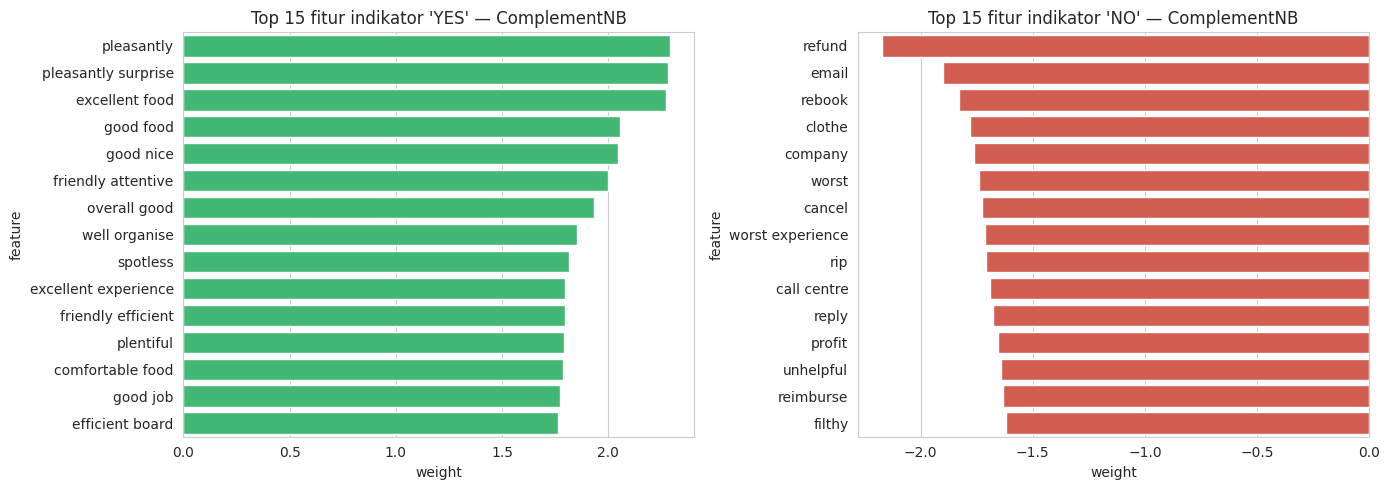

In [ ]:
# Top fitur per kelas — interpretasi model terbaik
feature_names = np.array(tfidf.get_feature_names_out())

if hasattr(best_model, 'coef_'):
    coefs = best_model.coef_.ravel()
    top_pos_idx = np.argsort(coefs)[-15:][::-1]
    top_neg_idx = np.argsort(coefs)[:15]
    top_pos = pd.DataFrame({'feature': feature_names[top_pos_idx], 'weight': coefs[top_pos_idx]})
    top_neg = pd.DataFrame({'feature': feature_names[top_neg_idx], 'weight': coefs[top_neg_idx]})
elif hasattr(best_model, 'feature_log_prob_'):
    log_prob_diff = best_model.feature_log_prob_[1] - best_model.feature_log_prob_[0]
    top_pos_idx = np.argsort(log_prob_diff)[-15:][::-1]
    top_neg_idx = np.argsort(log_prob_diff)[:15]
    top_pos = pd.DataFrame({'feature': feature_names[top_pos_idx], 'weight': log_prob_diff[top_pos_idx]})
    top_neg = pd.DataFrame({'feature': feature_names[top_neg_idx], 'weight': log_prob_diff[top_neg_idx]})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top_pos, x='weight', y='feature', ax=axes[0], color='#2ecc71')
axes[0].set_title(f"Top 15 fitur indikator 'YES' — {best_name}")
sns.barplot(data=top_neg, x='weight', y='feature', ax=axes[1], color='#e74c3c')
axes[1].set_title(f"Top 15 fitur indikator 'NO' — {best_name}")
plt.tight_layout()
plt.show()

### Inference Helper — Prediksi Review Baru + Confidence Level
Helper menerima list review baru, memprosesnya melalui pipeline yang **sama** dengan training, lalu mengembalikan label prediksi beserta **confidence (%)** berbasis probabilitas. Untuk `LinearSVC`, confidence diturunkan dari `decision_function` lewat sigmoid.

In [ ]:
def predict_sentiment(texts, model=None, vectorizer=None):
    """Prediksi sentiment + confidence level untuk satu/banyak review baru.

    Returns DataFrame dengan kolom:
      - review        : teks asli
      - cleaned       : teks setelah preprocessing
      - pred          : label biner (0/1)
      - sentiment     : 'yes (recommended)' / 'no (not recommended)'
      - confidence    : confidence kelas yang diprediksi (%)
      - prob_yes      : probabilitas kelas positif (%)
      - prob_no       : probabilitas kelas negatif (%)
    """
    if model is None:
        model = best_model
    if vectorizer is None:
        vectorizer = tfidf

    if isinstance(texts, str):
        texts = [texts]

    cleaned  = [clean_text(t) for t in texts]
    vec      = vectorizer.transform(cleaned)
    preds    = model.predict(vec)
    prob_yes = get_proba(model, vec)
    prob_no  = 1 - prob_yes
    confidence = np.where(preds == 1, prob_yes, prob_no)

    return pd.DataFrame({
        'review':       texts,
        'cleaned':      cleaned,
        'pred':         preds,
        'sentiment':    ['yes (recommended)' if p == 1 else 'no (not recommended)' for p in preds],
        'confidence':   [f'{c*100:.2f}%' for c in confidence],
        'prob_yes':     [f'{p*100:.2f}%' for p in prob_yes],
        'prob_no':      [f'{p*100:.2f}%' for p in prob_no],
    })

# Demo
demo_reviews = [
    "Excellent service, comfortable seats and friendly cabin crew. Highly recommended!",
    "Flight was delayed for 5 hours, lost my luggage and the staff was very rude. Never again.",
    "Decent food, on-time departure but seats are a bit cramped.",
    "Worst experience ever. Overpriced and uncomfortable.",
    "Crew was super polite, smooth boarding and the meal was surprisingly tasty.",
]

predict_sentiment(demo_reviews)

,review,cleaned,pred,sentiment,confidence,prob_yes,prob_no
0,"Excellent service, comfortable seats and frien...",excellent service comfortable friendly highly ...,1,yes (recommended),93.21%,93.21%,6.79%
1,"Flight was delayed for 5 hours, lost my luggag...",delay lose luggage rude never,0,no (not recommended),92.62%,7.38%,92.62%
2,"Decent food, on-time departure but seats are a...",decent food departure bite cramp,1,yes (recommended),69.20%,69.20%,30.80%
3,Worst experience ever. Overpriced and uncomfor...,worst experience ever overprice uncomfortable,0,no (not recommended),93.46%,6.54%,93.46%
4,"Crew was super polite, smooth boarding and the...",super polite smooth board meal surprisingly tasty,1,yes (recommended),87.54%,87.54%,12.46%


## 11. Diskusi

**Mengapa pipeline ini bekerja**
- **Custom airline stopwords** menghilangkan kata-kata generik (`flight`, `british`, `airways`, `seat`, dll.) yang muncul hampir merata di kedua kelas dan hanya menambah noise. Setelah dibuang, TF-IDF dan WordCloud lebih jelas memunculkan kata-kata diskriminatif (`delay`, `rude`, `cancel` vs `excellent`, `friendly`, `comfortable`).
- **Negation preservation** (`not`, `never`, `n't`, dst.) krusial — review *"not recommended"* setelah preprocessing tetap mengandung token `not recommend`, sehingga bigram TF-IDF dapat menangkap konteksnya.
- **Bigram TF-IDF** memungkinkan model menangkap frasa konteks (`good service`, `bad food`, `never again`) yang tidak bisa dilakukan unigram saja.
- **Class imbalance** ditangani dua arah: `stratify=y` saat split, `class_weight='balanced'` pada LR & SVM, serta **ComplementNB** yang memang dirancang untuk skenario imbalance.

**Mengapa menambahkan ComplementNB**
ComplementNB (Rennie et al., 2003) menghitung bobot fitur dari **komplemen kelas** sehingga bias terhadap kelas mayoritas berkurang signifikan. Pada banyak benchmark teks dengan distribusi miring, ComplementNB **mengungguli** MultinomialNB dengan biaya komputasi yang sama.

**Trade-off antar model**
- **Logistic Regression** — paling interpretable (bobot fitur langsung dapat dibaca) dan memberikan `predict_proba` native untuk confidence yang well-calibrated.
- **Linear SVM** — sering memberi akurasi tertinggi pada teks sparse, tapi tidak punya `predict_proba` native (kita gunakan sigmoid pada `decision_function` sebagai approximation).
- **Multinomial NB / ComplementNB** — paling cepat dilatih; menjadi baseline yang berharga dan tetap kompetitif.

**Sumber error utama**
Dari analisis error: kesalahan tipikal adalah review *campuran* ("good food **but** delayed 5 hours") dan review pendek/ambigu. Bigram membantu, tetapi sentimen yang membutuhkan reasoning multi-kalimat tetap menjadi tantangan untuk pendekatan bag-of-words.

**Arah pengembangan**
1. **Embedding kontekstual** seperti BERT / DistilBERT untuk menangkap nuansa multi-kalimat (umumnya +3–5% F1).
2. **SMOTE / oversampling** pada matriks TF-IDF jika imbalance sangat ekstrem.
3. **Calibration** model terbaik via `CalibratedClassifierCV` agar confidence lebih akurat untuk decision-making.

## 12. Kesimpulan

1. Dataset review British Airways berhasil diolah melalui pipeline lengkap **12 tahap** dari ingestion hingga inference.
2. **EDA** mengungkap distribusi kelas yang dapat divisualisasikan dengan **bar chart + pie chart proporsi sentimen (%)**, dan **WordCloud terpisah** menunjukkan kontras kosakata yang jelas antara review positif dan negatif.
3. **Praproses** menggunakan regex noise removal, stopwords bahasa Inggris **+ custom airline stopwords**, lemmatization, dan **mempertahankan kata negasi** untuk menjaga konteks sentimen.
4. **Vectorisasi TF-IDF** dengan `ngram_range=(1,2)`, `max_features=10000`, `sublinear_tf=True` menghasilkan representasi yang efektif untuk model linier.
5. Empat model (LR, LinearSVM, MultinomialNB, **ComplementNB**) dituning melalui `GridSearchCV` 5-fold stratified dengan grid yang lebih luas.
6. Evaluasi memakai **Accuracy, F1 weighted/macro, classification report, confusion matrix, dan ROC Curve (AUC)** — model terbaik dipilih otomatis berdasarkan F1 weighted di test set.
7. **Analisis error** memberikan insight tentang false positive/negative dan top fitur diskriminatif per kelas.
8. Helper `predict_sentiment()` memprediksi review baru sekaligus menampilkan **confidence level (%)** untuk setiap prediksi, siap dipakai sebagai layer inference produksi.

# Preprocessing

In [ ]:
# Ambil kolom yang relevan
df_clean = df[['content', 'recommended']].copy()

print('Sebelum drop NA:')
print(df_clean.isnull().sum())
print(f'Total: {len(df_clean)}')

# Hapus baris yang kosong
df_clean.dropna(subset=['content', 'recommended'], inplace=True)

print('\nSetelah drop NA:')
print(f'Total: {len(df_clean)}')

Sebelum drop NA:
content        0
recommended    0
dtype: int64
Total: 3616

Setelah drop NA:
Total: 3616


In [ ]:
# Normalisasi nilai recommended
df_clean['recommended'] = df_clean['recommended'].str.strip().str.lower()

print('Nilai unik recommended:', df_clean['recommended'].unique())

# Encode: yes=1 (Positif), no=0 (Negatif)
df_clean['label'] = df_clean['recommended'].map({'yes': 1, 'no': 0})

# Hapus baris dengan label tidak valid
df_clean.dropna(subset=['label'], inplace=True)
df_clean['label'] = df_clean['label'].astype(int)

print(f'\nDistribusi label:\n{df_clean["label"].value_counts()}')
print(f'\nTotal data valid: {len(df_clean)}')

Nilai unik recommended: ['no' 'yes']

Distribusi label:
label
0    2162
1    1454
Name: count, dtype: int64

Total data valid: 3616


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Kata-kata yang sering muncul tapi tidak informatif untuk konteks airline
custom_stopwords = {'flight', 'airline', 'would', 'also', 'got', 'get',
                    'one', 'us', 'back', 'even', 'still', 'said', 'told'}
stop_words.update(custom_stopwords)


def clean_text(text):
    """Pipeline pembersihan teks:
    1. Lowercase
    2. Hapus URL, email, angka, tanda baca
    3. Tokenisasi
    4. Hapus stopwords
    5. Lemmatisasi
    """
    if not isinstance(text, str):
        return ''

    # Lowercase
    text = text.lower()

    # Hapus URL dan email
    text = re.sub(r'http\S+|www\S+|\S+@\S+', '', text)

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Hapus tanda baca dan karakter khusus
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenisasi
    tokens = word_tokenize(text)

    # Hapus stopwords & token pendek
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Lemmatisasi
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# Terapkan ke seluruh data
df_clean['content_clean'] = df_clean['content'].apply(clean_text)

# Preview
print('Contoh hasil cleaning:\n')
for i in range(3):
    print(f'[ORIGINAL] {df_clean["content"].iloc[i][:120]}')
    print(f'[CLEAN]    {df_clean["content_clean"].iloc[i][:120]}')
    print()

Contoh hasil cleaning:

[ORIGINAL]  Just returned from Chicago, flew out 10 days ago on American Airlines absolutely superb in every way, had high expectat
[CLEAN]    returned chicago flew day ago american airline absolutely superb every way high expectation return disappointment airbus

[ORIGINAL]   BA standards continue to decline every time I fly with them. This time, a 45 min late departure, which seems the norm 
[CLEAN]    standard continue decline every time fly time min late departure seems norm information rude clueless boarding gate staf

[ORIGINAL]   Awful. Business class check in queue just as long as for economy, probably because half of the desks were not staffed 
[CLEAN]    awful business class check queue long economy probably half desk staffed terminal chaotic business lounge overfull seat 



In [ ]:
# Hapus baris yang teks bersihnya kosong
df_clean = df_clean[df_clean['content_clean'].str.strip() != '']
print(f'Data siap: {len(df_clean)} baris')

Data siap: 3616 baris


# EDA

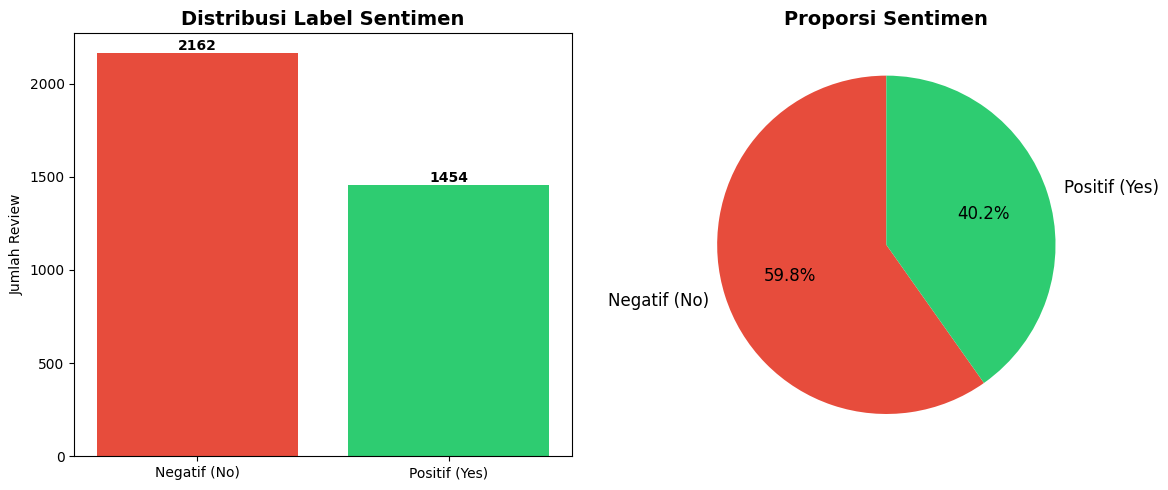


Rasio Positif:Negatif = 1454:2162


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
label_counts = df_clean['label'].value_counts()
label_names = {0: 'Negatif (No)', 1: 'Positif (Yes)'}
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(
    [label_names[k] for k in label_counts.index],
    label_counts.values,
    color=colors
)
axes[0].set_title('Distribusi Label Sentimen', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Review')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[label_names[k] for k in label_counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Proporsi Sentimen', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRasio Positif:Negatif = {label_counts[1]}:{label_counts[0]}')

## Distribusi label menunjukkan:
Negatif (0 / no) = 2162 data
Positif (1 / yes) = 1454 data

Artinya dataset cenderung lebih banyak berisi pengalaman negatif dibanding positif.

## Insight
Ini cukup umum pada dataset review maskapai karena:
pelanggan lebih terdorong menulis review saat kecewa
pengalaman buruk lebih sering memicu feedback panjang

## Implikasi ke Modeling
Dataset sedikit imbalanced, tetapi belum terlalu parah.
Proporsi:
Negatif ≈ 59.8%
Positif ≈ 40.2%

Masih aman untuk:
sentiment classification
clustering
topic modeling
Tetapi nanti saat training model supervised:
bisa gunakan class_weight='balanced'
atau evaluasi pakai F1-score, bukan accuracy saja

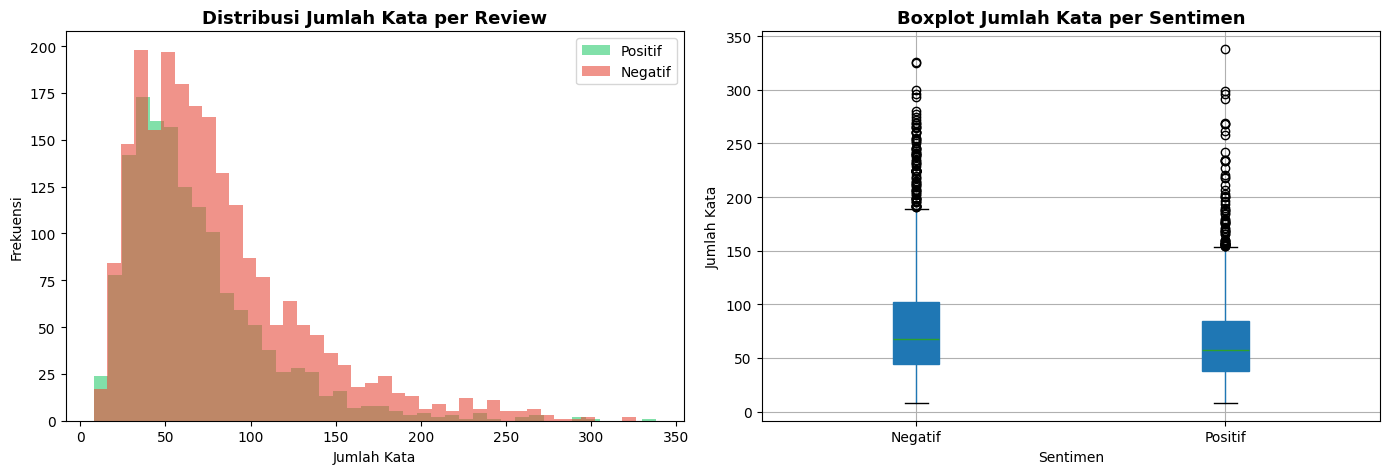


Statistik jumlah kata:
           count   mean    std  min   25%   50%    75%    max
sentimen                                                     
Negatif   2162.0  80.19  49.90  8.0  44.0  68.0  102.0  326.0
Positif   1454.0  67.47  42.04  8.0  38.0  57.0   84.0  338.0


In [ ]:
df_clean['word_count'] = df_clean['content_clean'].apply(lambda x: len(x.split()))
df_clean['char_count'] = df_clean['content_clean'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label_val, color, name in [(1, '#2ecc71', 'Positif'), (0, '#e74c3c', 'Negatif')]:
    subset = df_clean[df_clean['label'] == label_val]['word_count']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name)

axes[0].set_title('Distribusi Jumlah Kata per Review', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot word count per label
df_clean['sentimen'] = df_clean['label'].map({1: 'Positif', 0: 'Negatif'})
df_clean.boxplot(column='word_count', by='sentimen', ax=axes[1], patch_artist=True)
axes[1].set_title('Boxplot Jumlah Kata per Sentimen', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah Kata')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_word_count.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStatistik jumlah kata:')
print(df_clean.groupby('sentimen')['word_count'].describe().round(2))

## Histogram Distribusi Kata
Graph menunjukkan distribusi jumlah kata untuk review positif dan negatif.

## Temuan Utama
Kedua distribusi bersifat right-skewed
mayoritas review pendek-menengah
sedikit review sangat panjang
Review negatif terlihat:
lebih menyebar
memiliki ekor distribusi lebih panjang
lebih banyak review dengan >100 kata
## Interpretasi
Reviewer negatif cenderung:
menjelaskan detail masalah
memberikan kronologi pengalaman buruk
meluapkan frustrasi lebih panjang
Sedangkan review positif:
lebih singkat
langsung menyampaikan kepuasan
## Contoh pola umum:
Positif:
“Great service and comfortable seat.”
Negatif:
“Flight delayed 4 hours, rude staff, luggage missing, terrible communication…”

## Analisis Boxplot Jumlah Kata per Sentimen
## Temuan Utama
Median review negatif lebih tinggi daripada positif
Artinya review negatif rata-rata lebih panjang
Variabilitas
IQR negatif lebih besar
Review negatif lebih variatif

## Outlier
Banyak outlier di kedua kelas:
ada review hingga 300+ kata
Namun outlier negatif tampak lebih banyak dan lebih padat.

## Insight Bisnis

Ketika pelanggan kecewa:
* mereka lebih terdorong memberi detail
* lebih emosional
* lebih banyak menjelaskan pengalaman

Ini insight penting karena:
* panjang review sendiri bisa menjadi feature sentiment.

Nanti bisa dipakai:
* feature engineering (word_count)
* auxiliary feature untuk model ML

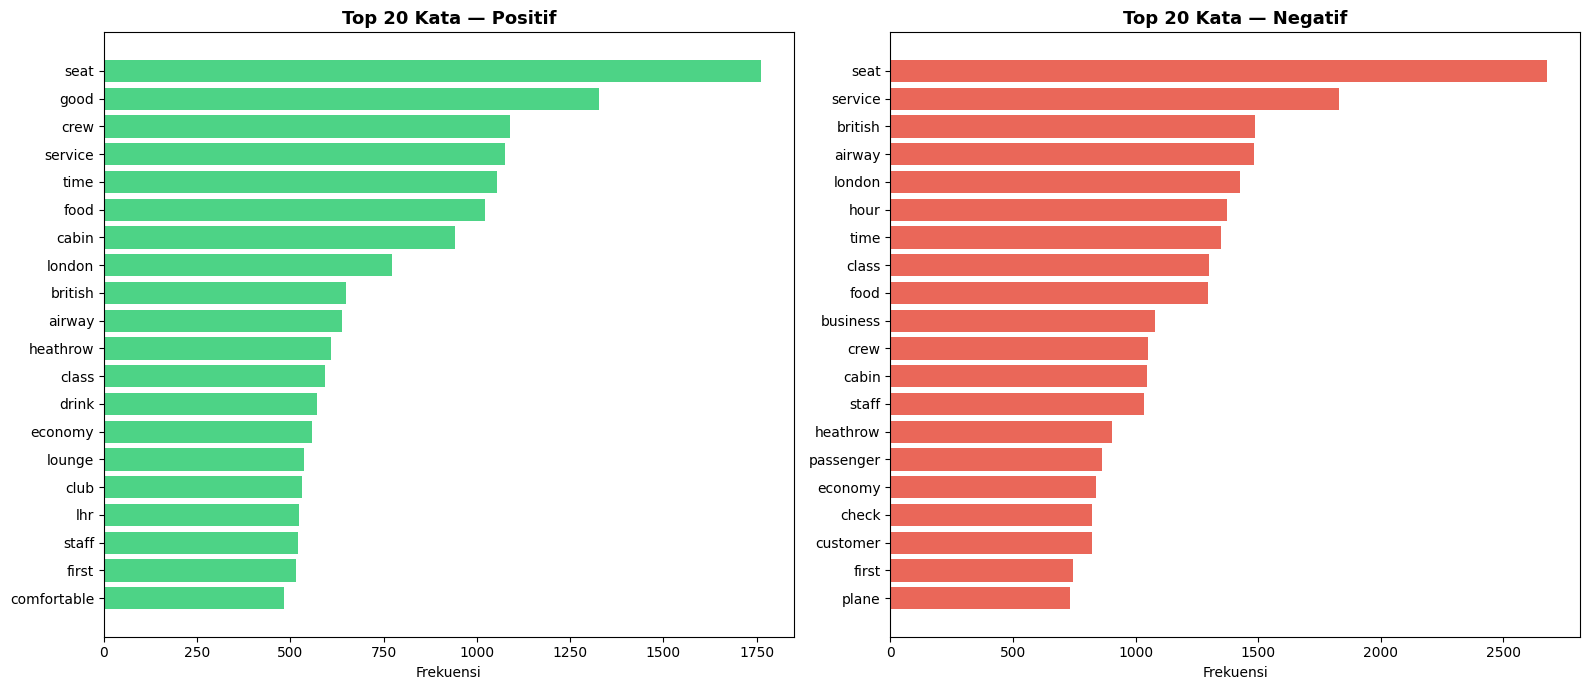

In [ ]:
from collections import Counter

def get_top_words(df, label, n=20):
    text = ' '.join(df[df['label'] == label]['content_clean'])
    words = text.split()
    return Counter(words).most_common(n)

top_pos = get_top_words(df_clean, 1)
top_neg = get_top_words(df_clean, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in [
    (axes[0], top_pos, 'Top 20 Kata — Positif', '#2ecc71'),
    (axes[1], top_neg, 'Top 20 Kata — Negatif', '#e74c3c')
]:
    words, counts = zip(*data)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis Top 20 Kata — Positif
### Kata Dominan

Kata paling sering:

good
crew
service
comfortable
friendly
excellent
Interpretasi

Review positif fokus pada:

Kualitas pelayanan
crew
service
staff
Kenyamanan
seat
comfortable
cabin
Pengalaman keseluruhan
excellent
well
great

## Insight Bisnis

Faktor kepuasan utama pelanggan tampaknya:

* pelayanan kru
* kenyamanan kursi
* kualitas makanan/minuman
* pengalaman penerbangan yang lancar

## Analisis Top 20 Kata — Negatif
### Kata Dominan

Muncul kata:
hour
time
check
customer
airport
delayed
call
bag
boarding
Interpretasi

Review negatif lebih fokus pada:
Masalah operasional
delay
waiting time
boarding
airport process
Customer service
customer
call
staff
Bagasi & administrasi
luggage
bag
check

## Insight Penting

Keluhan terbesar tampaknya bukan hanya kualitas kursi/makanan, tetapi:

masalah operasional dan komunikasi layanan.

Ini sangat umum di industri airline.

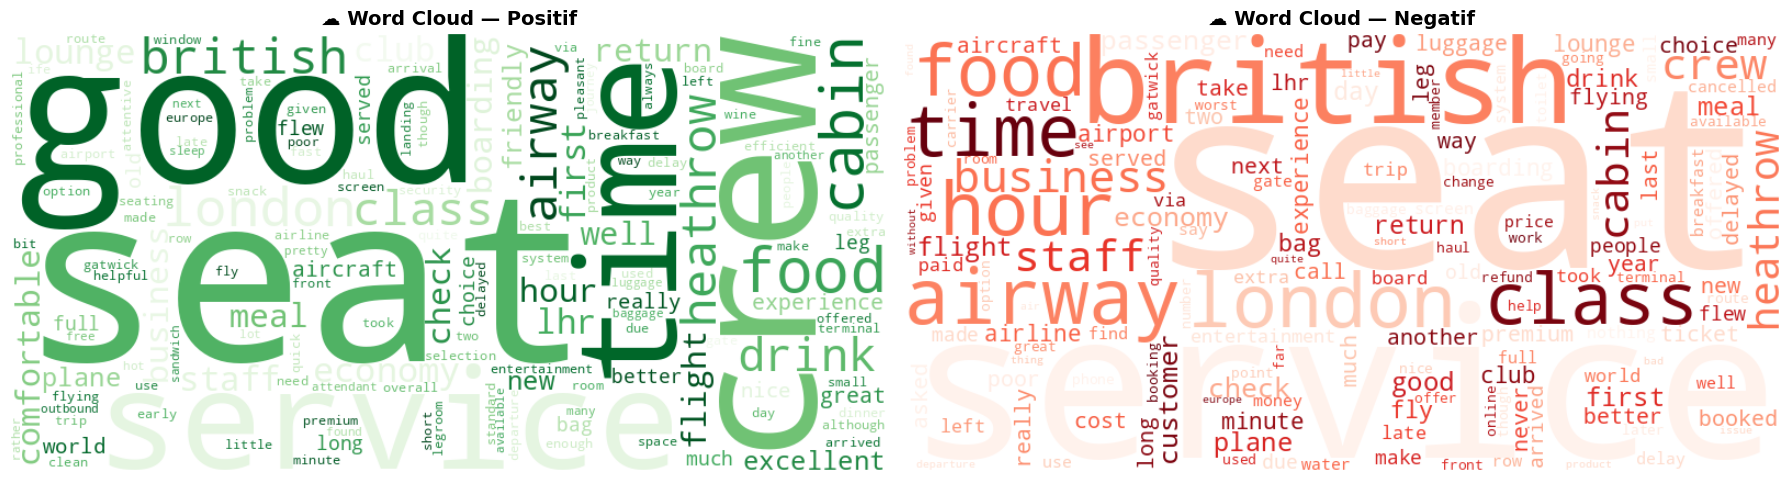

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, label, title, cmap in [
    (axes[0], 1, '☁️ Word Cloud — Positif', 'Greens'),
    (axes[1], 0, '☁️ Word Cloud — Negatif', 'Reds')
]:
    text = ' '.join(df_clean[df_clean['label'] == label]['content_clean'])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=cmap,
        max_words=150,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis Word Cloud Positif
Karakteristik

Word cloud positif didominasi:
good
service
crew
cabin
friendly
comfortable
Makna

Sentimen positif berkaitan dengan:
keramahan staf
kenyamanan kabin
pengalaman penerbangan yang nyaman

Bahasa positif cenderung:
pendek
langsung
evaluatif

## Analisis Word Cloud Negatif
Karakteristik

Dominasi:
seat
service
british
airway
hour
time

Disertai:
delayed
customer
boarding
problem
cancelled
Makna

Review negatif:
lebih detail
lebih berorientasi masalah
lebih banyak menyebut proses perjalanan

## Insight Global Dataset
Dataset Sangat Bagus untuk Sentiment Analysis

Karena:
Ada pemisahan vocabulary yang cukup jelas

Positif:
good
excellent
friendly
comfortable

Negatif:
delayed
hour
customer
problem

Ini bagus untuk:
TF-IDF
Logistic Regression
SVM
Naive Bayes
bahkan clustering

# TF-IDF

In [ ]:
X = df_clean['content_clean']
y = df_clean['label']

# Train-test split dengan stratify supaya proporsi label terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train)}')
print(f'Test size  : {len(X_test)}')
print(f'\nDistribusi label train:\n{y_train.value_counts()}')
print(f'\nDistribusi label test:\n{y_test.value_counts()}')

Train size : 2892
Test size  : 724

Distribusi label train:
label
0    1729
1    1163
Name: count, dtype: int64

Distribusi label test:
label
0    433
1    291
Name: count, dtype: int64


In [ ]:
# TF-IDF Unigram + Bigram
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),       # unigram dan bigram
    max_features=15000,        # batasi fitur
    min_df=3,                  # abaikan term yang muncul < 3 dokumen
    max_df=0.90,               # abaikan term yang muncul di > 90% dokumen
    sublinear_tf=True,         # gunakan log TF untuk mengurangi dominasi kata berulang
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Shape matrix train : {X_train_tfidf.shape}')
print(f'Shape matrix test  : {X_test_tfidf.shape}')
print(f'Jumlah fitur (n-gram): {len(tfidf.vocabulary_):,}')

Shape matrix train : (2892, 15000)
Shape matrix test  : (724, 15000)
Jumlah fitur (n-gram): 15,000


In [ ]:
# Lihat 20 fitur dengan IDF tertinggi (kata yang paling diskriminatif)
feature_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_

top_idf_idx = np.argsort(idf_scores)[::-1][:20]
print('Top 20 fitur berdasarkan IDF score:')
for idx in top_idf_idx:
    print(f'  {feature_names[idx]:<30} IDF: {idf_scores[idx]:.4f}')

Top 20 fitur berdasarkan IDF score:
  long overnight                 IDF: 7.5838
  long short                     IDF: 7.5838
  long staff                     IDF: 7.5838
  zrh lhr                        IDF: 7.5838
  able sleep                     IDF: 7.5838
  young male                     IDF: 7.5838
  zagreb                         IDF: 7.5838
  accessed                       IDF: 7.5838
  acknowledgement                IDF: 7.5838
  london really                  IDF: 7.5838
  london santiago                IDF: 7.5838
  london service                 IDF: 7.5838
  london shanghai                IDF: 7.5838
  look business                  IDF: 7.5838
  look good                      IDF: 7.5838
  look premium                   IDF: 7.5838
  looked forward                 IDF: 7.5838
  looked new                     IDF: 7.5838
  london take                    IDF: 7.5838
  london via                     IDF: 7.5838


# Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',   # tangani imbalance kelas
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tfidf, y_train)

✅ Model selesai dilatih!


In [ ]:
y_pred  = rf.predict(X_test_tfidf)
y_proba = rf.predict_proba(X_test_tfidf)[:, 1]

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Negatif (0)', 'Positif (1)'],
    digits=4
))

Accuracy : 0.8066 (80.66%)
ROC-AUC  : 0.8548

Classification Report:
              precision    recall  f1-score   support

 Negatif (0)     0.8447    0.8291    0.8368       433
 Positif (1)     0.7525    0.7732    0.7627       291

    accuracy                         0.8066       724
   macro avg     0.7986    0.8011    0.7998       724
weighted avg     0.8076    0.8066    0.8070       724



## Analisis Hasil Model Sentiment Classification

Model yang digunakan:

Random Forest
TF-IDF Unigram + Bigram
n_estimators = 200

dengan target:

0 = Negatif
1 = Positif

## Analisis Performa Umum Model
Accuracy = 80.66%

Model berhasil mengklasifikasikan sekitar:

8 dari 10 review dengan benar.

Untuk sentiment analysis berbasis teks review maskapai, angka ini tergolong:

baik
cukup stabil
menunjukkan pola sentimen berhasil dipelajari model

Karena:

data teks bersifat noisy
banyak opini ambigu
terdapat campuran kata positif dan negatif dalam satu review

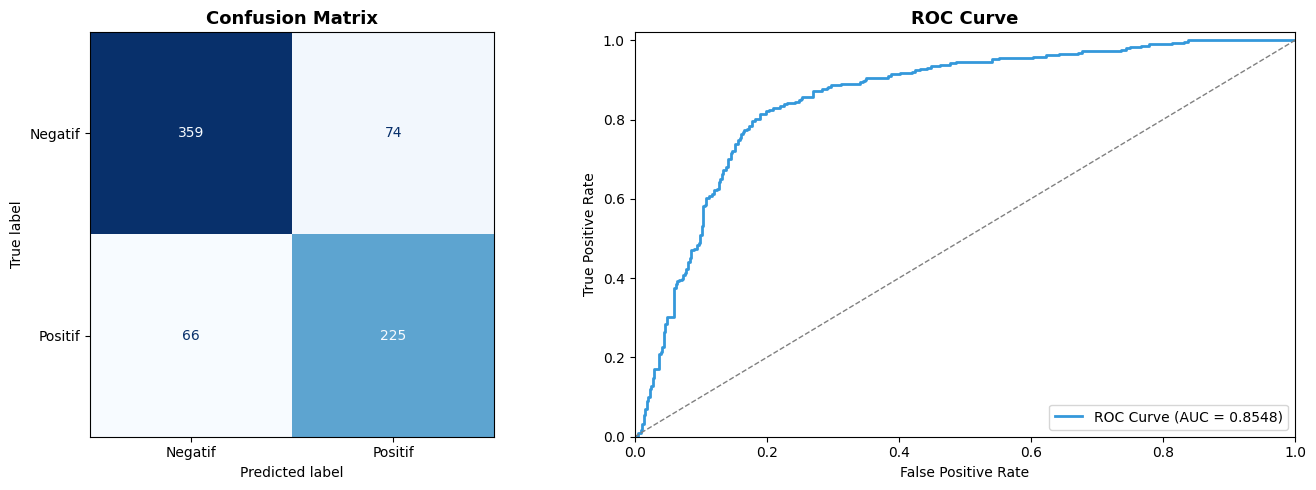

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negatif', 'Positif']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#3498db', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('result_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretasi Detail
True Negative = 359

Review negatif yang berhasil dikenali dengan benar.

Ini menunjukkan model cukup kuat mengenali:

complaint
delay
service issue
frustration words
True Positive = 225

Review positif yang berhasil diprediksi benar.

Menandakan model memahami:

praise words
satisfaction patterns
positive experience vocabulary
False Positive = 74

Review negatif tetapi diprediksi positif.

Kemungkinan penyebab:

review mengandung campuran kata positif dan negatif

Contoh:

“Crew was friendly but the flight was delayed 5 hours.”

Model mungkin fokus ke kata:

friendly
good
crew

dan gagal memahami konteks negatif utama.

False Negative = 66

Review positif diprediksi negatif.

Kemungkinan:

review positif menggunakan bahasa netral
terlalu sedikit kata positif eksplisit

Contoh:

“Flight was acceptable overall.”

In [ ]:
# Cross-val pada data train
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf, X_train_tfidf, y_train,
    cv=skf, scoring='accuracy', n_jobs=-1
)

print('Cross-Validation Accuracy (5-Fold):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation Accuracy (5-Fold):
  Fold 1: 0.8169
  Fold 2: 0.8169
  Fold 3: 0.8253
  Fold 4: 0.7872
  Fold 5: 0.8010
  Mean : 0.8095 ± 0.0136


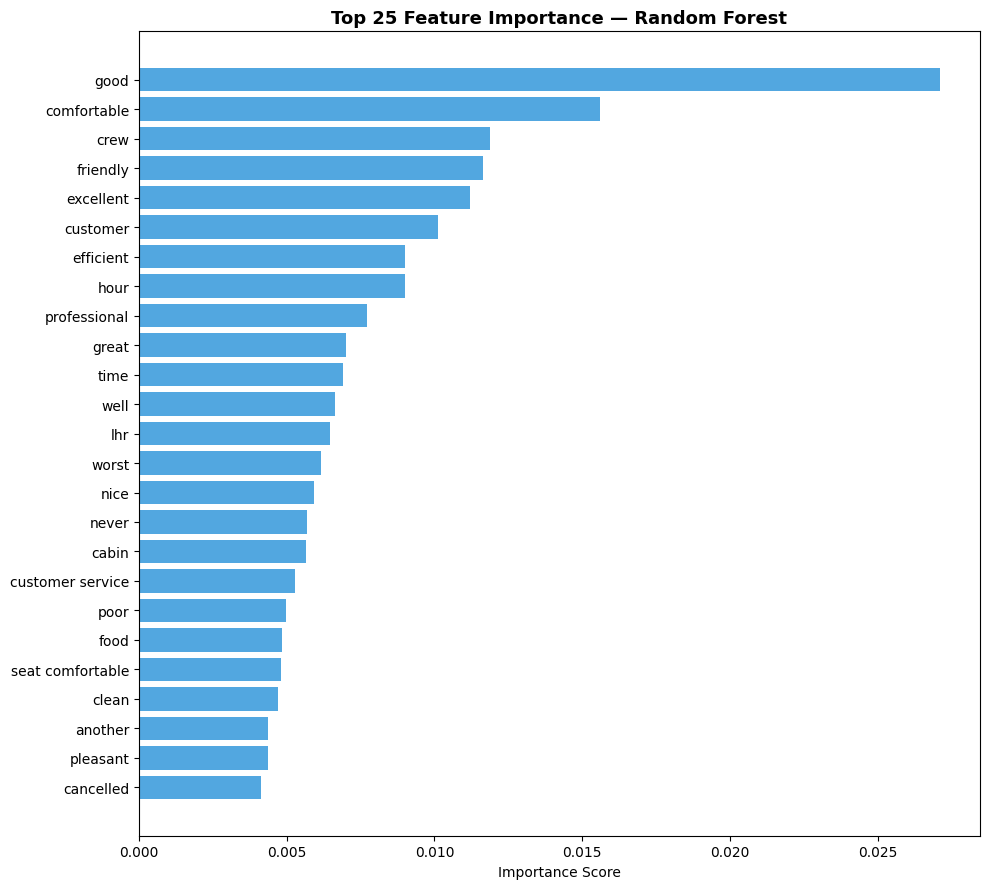


Top 25 fitur:
  good                                0.027108
  comfortable                         0.015607
  crew                                0.011868
  friendly                            0.011649
  excellent                           0.011191
  customer                            0.010124
  efficient                           0.008999
  hour                                0.008990
  professional                        0.007711
  great                               0.007013
  time                                0.006900
  well                                0.006642
  lhr                                 0.006464
  worst                               0.006157
  nice                                0.005918
  never                               0.005672
  cabin                               0.005644
  customer service                    0.005267
  poor                                0.004961
  food                                0.004847
  seat comfortable                    0.00479

In [ ]:
importances = rf.feature_importances_
top_n = 25
top_idx = np.argsort(importances)[::-1][:top_n]

top_features = [(feature_names[i], importances[i]) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 9))
words_fi, scores_fi = zip(*top_features)

colors_fi = ['#3498db'] * top_n
ax.barh(list(reversed(words_fi)), list(reversed(scores_fi)),
        color=list(reversed(colors_fi)), alpha=0.85)
ax.set_title(f'Top {top_n} Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('result_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 25 fitur:')
for w, s in top_features:
    print(f'  {w:<35} {s:.6f}')

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = {
    'Metrik'  : ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)', 'ROC-AUC', 'CV Accuracy (mean)'],
    'Score'   : [
        f'{acc:.4f}',
        f'{precision_score(y_test, y_pred, average="macro"):.4f}',
        f'{recall_score(y_test, y_pred, average="macro"):.4f}',
        f'{f1_score(y_test, y_pred, average="macro"):.4f}',
        f'{roc_auc:.4f}',
        f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}'
    ]
}

df_summary = pd.DataFrame(summary)
print('=' * 45)
print('       RINGKASAN EVALUASI MODEL')
print('=' * 45)
print(df_summary.to_string(index=False))
print('=' * 45)
print(f'\nModel       : Random Forest (n_estimators=200)')
print(f'Vectorizer  : TF-IDF Unigram + Bigram (max_features=15000)')
print(f'Train size  : {len(X_train)}')
print(f'Test size   : {len(X_test)}')

       RINGKASAN EVALUASI MODEL
            Metrik           Score
          Accuracy          0.8066
 Precision (macro)          0.7986
    Recall (macro)          0.8011
  F1-Score (macro)          0.7998
           ROC-AUC          0.8548
CV Accuracy (mean) 0.8095 ± 0.0136

Model       : Random Forest (n_estimators=200)
Vectorizer  : TF-IDF Unigram + Bigram (max_features=15000)
Train size  : 2892
Test size   : 724


# Prediksi Review Baru

In [ ]:
def predict_sentiment(texts: list[str]) -> None:
    """Prediksi sentimen dari list teks review."""
    cleaned = [clean_text(t) for t in texts]
    vec     = tfidf.transform(cleaned)
    preds   = rf.predict(vec)
    probas  = rf.predict_proba(vec)

    print(f'{"Review":<60} {"Sentimen":<12} {"Confidence"}')
    print('-' * 90)
    for text, pred, proba in zip(texts, preds, probas):
        label      = 'Positif ✅' if pred == 1 else 'Negatif ❌'
        confidence = f'{max(proba)*100:.1f}%'
        snippet    = text[:57] + '...' if len(text) > 60 else text
        print(f'{snippet:<60} {label:<12} {confidence}')


sample_reviews = [
    "Excellent service, the crew was very professional and friendly throughout the whole journey.",
    "Terrible experience. Flight delayed 4 hours, no communication, staff was rude.",
    "Seat was comfortable, food was decent. Nothing spectacular but overall okay.",
    "Lost my luggage and customer service refused to help. Never flying with them again!",
    "Clean aircraft, on-time departure, and amazing cabin crew. Highly recommend!"
]

predict_sentiment(sample_reviews)

Review                                                       Sentimen     Confidence
------------------------------------------------------------------------------------------
Excellent service, the crew was very professional and fri... Positif ✅    75.8%
Terrible experience. Flight delayed 4 hours, no communica... Negatif ❌    84.9%
Seat was comfortable, food was decent. Nothing spectacula... Positif ✅    64.4%
Lost my luggage and customer service refused to help. Nev... Negatif ❌    86.2%
Clean aircraft, on-time departure, and amazing cabin crew... Positif ✅    74.0%


## Kesimpulan Akhir

Model Random Forest dengan TF-IDF unigram dan bigram berhasil memberikan performa yang baik dalam klasifikasi sentimen review maskapai dengan accuracy sebesar 80.66% dan ROC-AUC sebesar 0.8548. Model mampu membedakan review positif dan negatif secara efektif, terutama pada review negatif yang memiliki pola vocabulary lebih spesifik seperti “cancelled”, “worst”, dan “hour”.

Hasil confusion matrix menunjukkan sebagian besar review berhasil diklasifikasikan dengan benar, sementara kesalahan prediksi umumnya terjadi pada review dengan sentimen campuran atau bahasa yang ambigu. Selain itu, hasil cross-validation yang stabil menunjukkan model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting secara signifikan.

Feature importance memperlihatkan bahwa sentimen positif banyak dipengaruhi oleh kata-kata terkait pelayanan dan kenyamanan seperti “good”, “comfortable”, dan “friendly”, sedangkan sentimen negatif didominasi oleh isu operasional seperti delay, customer service, dan pembatalan penerbangan.